In [33]:
import logging
import numpy as np
import sklearn
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler

In [34]:
# prompt: mount google drive in this ipynb

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
# prompt: write code to unzip data and save it in drive

import zipfile
import os

# Define the path to the zip file in your Google Drive
zip_file_path = '/content/drive/MyDrive/FYP/data/data.zip'  # Replace with your actual path

# Define the directory where you want to extract the data
extract_path = '/content/drive/My Drive/FYP/data/unzipped' # Replace with your desired path

# Create the extract directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

try:
  with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
  print(f'Successfully unzipped {zip_file_path} to {extract_path}')
except FileNotFoundError:
  print(f'Error: Zip file not found at {zip_file_path}')
except Exception as e:
  print(f'An error occurred: {e}')


Successfully unzipped /content/drive/MyDrive/FYP/data/data.zip to /content/drive/My Drive/FYP/data/unzipped


The line logger = logging.getLogger(__name__) creates a logger object specifically for the current module, using the module's name to identify it. This helps you track events and messages in a structured way, making it easier to understand and debug your code.

In [36]:
logger = logging.getLogger(__name__)


In summary, the get_train function loads training data from files, filters it to include only samples where the target variable (y) is 0, potentially scales the features, and then returns the processed training data.

In [37]:
def get_train(*args):
    x = np.load('/content/drive/MyDrive/FYP/data/unzipped/ali_train_x.npy').astype(np.float32)
    y = np.load('/content/drive/MyDrive/FYP/data/unzipped/ali_train_y.npy').astype(np.float32)
    # (184602, 16) (184602,)
    # 184532 : 70
    ind = [y==0]
    x_train = x[ind]
    y_train = y[ind]

    scaler = MinMaxScaler()
    scaler.fit(x_train)
    scaler.transform(x_train)

    return x_train, y_train


Okay, let's break down the get_test function:

This function is designed to prepare a testing dataset for a machine learning model, likely for anomaly detection. Here's a step-by-step explanation:

Initialization and Data Loading:

rng = np.random.RandomState(42)
   x = np.load('/content/drive/MyDrive/FYP/data/unzipped/ali_test_x.npy').astype(np.float32)
   y = np.load('/content/drive/MyDrive/FYP/data/unzipped/ali_test_y.npy').astype(np.float32)
Use code with caution
rng = np.random.RandomState(42): This line creates a random number generator (rng) with a fixed seed (42). Using a seed ensures that the random operations within the function produce the same results each time it's run, making the process reproducible.
x = np.load(...): This loads the feature data (likely the input data for the model) from a file named 'ali_test_x.npy' located in your Google Drive. It's converted to np.float32 data type.
y = np.load(...): This loads the target variable data (likely the labels indicating whether a data point is an anomaly or not) from a file named 'ali_test_y.npy', also converted to np.float32.
Separating Major and Minor Classes:

x_major = x[y==0]
   y_major = y[y==0]
   x_minor = x[y==1]
   y_minor = y[y==1]
Use code with caution
These lines separate the data into two groups based on the target variable (y):
x_major, y_major: Contain data points where y is 0 (likely representing the normal or majority class).
x_minor, y_minor: Contain data points where y is 1 (likely representing the anomalous or minority class).
Controlling Class Proportion:

idx = [t for t in range(0, 70602, 7)]
   x_major = x_major[idx]
   y_major = y_major[idx]
Use code with caution
This part aims to adjust the proportion of the majority class (x_major, y_major) in the dataset.
idx = [t for t in range(0, 70602, 7)]: This creates a list of indices (idx) by stepping through the range 0 to 70602 with a step of 7. This effectively selects every 7th element.
x_major = x_major[idx] and y_major = y_major[idx]: These lines use the idx list to select a subset of the majority class data, reducing its size. This is likely done to balance the dataset or to simulate a scenario where anomalies are rare.
Calculating Contamination Rate:

contaminate_rate = len(y_minor) / (len(y_minor) + len(y_major))
Use code with caution
This line calculates the contaminate_rate, which represents the proportion of anomalous samples in the dataset. It's calculated as the number of anomalous samples (len(y_minor)) divided by the total number of samples.
Shuffling Data:

size_major = x_major.shape[0]
   inds = rng.permutation(size_major)
   x_major, y_major = x_major[inds], y_major[inds]

   size_minor = x_minor.shape[0]
   inds = rng.permutation(size_minor)
   x_minor, y_minor = x_minor[inds], y_minor[inds]
Use code with caution
This section shuffles the data points within both the majority and minority classes.
size_major, size_minor: These variables store the number of data points in each class.
rng.permutation(...): This function generates a random permutation of indices based on the size of each class.
The data points in x_major, y_major, x_minor, and y_minor are then reordered using these permuted indices. Shuffling helps ensure that the model doesn'

In [38]:
# Get testing dataset for ali
def get_test(*args):
	# seed shuffling
    rng = np.random.RandomState(42)
    x = np.load('/content/drive/MyDrive/FYP/data/unzipped/ali_test_x.npy').astype(np.float32)
    y = np.load('/content/drive/MyDrive/FYP/data/unzipped/ali_test_y.npy').astype(np.float32)

    # (70637, 16) (70637,)
    # 70602 : 35

    x_major = x[y==0]
    y_major = y[y==0]
    x_minor = x[y==1]
    y_minor = y[y==1]

    # control the proportion of positive and negtive samples
    idx = [t for t in range(0, 70602, 7)]
    x_major = x_major[idx]
    y_major = y_major[idx]

	# contaminate_rate : the empirical ratio of anomalous samples = anomalous / (normal + anomalous)
    contaminate_rate = len(y_minor) / (len(y_minor) + len(y_major))

    size_major = x_major.shape[0]
    inds = rng.permutation(size_major)
    x_major, y_major = x_major[inds], y_major[inds]

    size_minor = x_minor.shape[0]
    inds = rng.permutation(size_minor)
    x_minor, y_minor = x_minor[inds], y_minor[inds]

    x_test = np.concatenate((x_major, x_minor), axis=0)
    y_test = np.concatenate((y_major, y_minor), axis=0)

    size_test = x_test.shape[0]
    inds = rng.permutation(size_test)
    x_test, y_test = x_test[inds], y_test[inds]

    scaler = MinMaxScaler()
    scaler.fit(x_test)
    scaler.transform(x_test)

    return x_test, y_test, contaminate_rate

Okay, let's break down the _get_dataset() function:

Function Purpose
This function is designed to load, preprocess, and prepare a dataset for machine learning, specifically for anomaly detection. It reads data from a CSV file, performs several transformations, and then splits it into training and testing sets.

Step-by-Step Explanation
Data Loading and Column Naming:

col_names = _col_names()
   df = pd.read_csv("/content/drive/MyDrive/FYP/data/kddcup.data_10_percent_corrected", header=None, names=col_names)
Use code with caution
col_names = _col_names(): This line assumes there's another function called _col_names() that is defined elsewhere in the code. It's likely used to retrieve or generate the names of the columns for the dataset.
df = pd.read_csv(...): This line uses the pandas library (pd) to read the data from a CSV file located in your Google Drive. The header=None argument indicates that the file doesn't have a header row with column names. The names=col_names argument assigns the column names retrieved from _col_names() to the DataFrame (df).
Encoding Categorical Features:

text_l = ['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login']
   for name in text_l:
       _encode_text_dummy(df, name)
Use code with caution
text_l = [...]: This line defines a list of column names (text_l) that likely contain categorical data (text values).
The for loop iterates through each column name in text_l.
_encode_text_dummy(df, name): This line calls another function, presumably called _encode_text_dummy(), to convert the categorical features in the specified column (name) into numerical representations using a technique like one-hot encoding. This is often necessary for machine learning algorithms to work with categorical data.
Label Transformation:

labels = df['label'].copy()  
   labels[labels != 'normal.'] = 1
   labels[labels == 'normal.'] = -1
   df['label'] = labels
Use code with caution
labels = df['label'].copy(): This creates a copy of the 'label' column from the DataFrame and assigns it to the labels variable.
The next two lines remap the values in the labels variable:
labels[labels != 'normal.'] = 1: Values that are not 'normal.' are changed to 1 (likely representing anomalies).
labels[labels == 'normal.'] = -1: Values that are 'normal.' are changed to -1 (likely representing the normal class).
df['label'] = labels: The modified labels are assigned back to the 'label' column in the DataFrame.
Data Splitting:

df_train = df.sample(frac=0.5, random_state=42)
   df_test = df.loc[~df.index.isin(df_train.index)]
Use code with caution
df_train = df.sample(...): This line randomly samples 50% (frac=0.5) of the data from the DataFrame (df) and assigns it to df_train, which will be used for training the model. The random_state=42 ensures that the sampling is reproducible.
df_test = df.loc[...]: This line selects the remaining data that was not included in df_train and assigns it to df_test, which will be used for testing the model.
Feature and Target Separation:

x_train, y_train = _to_xy(df_train, target='label')  
   y_train = y_train.flatten().astype(int)
   x_test, y_test = _to_xy(df_test, target='label')  
   y_test = y_test.flatten().astype(int)
Use code with caution
These lines call a function, presumably named _to_xy(), to separate the features (input data) from the target variable (labels) in both the training and testing sets

In [39]:
def _get_dataset():
    """ Gets the basic dataset
    Returns :
            dataset (dict): containing the data
                dataset['x_train'] (np.array): training images shape
                (?, 120)
                dataset['y_train'] (np.array): training labels shape
                (?,)
                dataset['x_test'] (np.array): testing images shape
                (?, 120)
                dataset['y_test'] (np.array): testing labels shape
                (?,)
    """
    col_names = _col_names()
    df = pd.read_csv("/content/drive/MyDrive/FYP/data/kddcup.data_10_percent_corrected", header=None, names=col_names)

    text_l = ['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login']

    for name in text_l:
        _encode_text_dummy(df, name)

    labels = df['label'].copy()
    # Given the ratio of normal(less) and abnormal samples(more), suppose preponderant samples are normal
    # Isolation Tree regards the dominant labels as 1(normal), and the less as -1(abnormal)
    labels[labels != 'normal.'] = 1
    labels[labels == 'normal.'] = -1

    df['label'] = labels

    df_train = df.sample(frac=0.5, random_state=42)
    df_test = df.loc[~df.index.isin(df_train.index)]

    x_train, y_train = _to_xy(df_train, target='label')
    y_train = y_train.flatten().astype(int)
    x_test, y_test = _to_xy(df_test, target='label')
    y_test = y_test.flatten().astype(int)

    # x_train = x_train[y_train != 1]
    # y_train = y_train[y_train != 1]

    scaler = MinMaxScaler()
    scaler.fit(x_train)
    scaler.transform(x_train)
    scaler.transform(x_test)

    dataset = {}
    dataset['x_train'] = x_train.astype(np.float32)
    dataset['y_train'] = y_train.astype(np.float32)
    dataset['x_test'] = x_test.astype(np.float32)
    dataset['y_test'] = y_test.astype(np.float32)

    return dataset


In [40]:
def _get_adapted_dataset(split):
    """ Gets the adapted dataset for the experiments

    Args :
            split (str): train or test
    Returns :
            (tuple): <training, testing> images and labels
    """
    dataset = _get_dataset()
    key_img = 'x_' + split
    key_lbl = 'y_' + split

    if split != 'train':
        dataset[key_img], dataset[key_lbl] = _adapt(dataset[key_img],
                                                    dataset[key_lbl])

    return (dataset[key_img], dataset[key_lbl])


In [41]:
def _get_dataset():
    """ Gets the basic dataset
    Returns :
            dataset (dict): containing the data
                dataset['x_train'] (np.array): training images shape
                (?, 120)
                dataset['y_train'] (np.array): training labels shape
                (?,)
                dataset['x_test'] (np.array): testing images shape
                (?, 120)
                dataset['y_test'] (np.array): testing labels shape
                (?,)
    """
    col_names = _col_names()
    df = pd.read_csv("/content/drive/MyDrive/FYP/data/kddcup.data_10_percent_corrected", header=None, names=col_names)

    text_l = ['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login']

    for name in text_l:
        _encode_text_dummy(df, name)

    labels = df['label'].copy()
    # Given the ratio of normal(less) and abnormal samples(more), suppose preponderant samples are normal
    # Isolation Tree regards the dominant labels as 1(normal), and the less as -1(abnormal)
    labels[labels != 'normal.'] = 1
    labels[labels == 'normal.'] = -1

    df['label'] = labels

    df_train = df.sample(frac=0.5, random_state=42)
    df_test = df.loc[~df.index.isin(df_train.index)]

    x_train, y_train = _to_xy(df_train, target='label')
    y_train = y_train.flatten().astype(int)
    x_test, y_test = _to_xy(df_test, target='label')
    y_test = y_test.flatten().astype(int)

    # x_train = x_train[y_train != 1]
    # y_train = y_train[y_train != 1]

    scaler = MinMaxScaler()
    scaler.fit(x_train)
    scaler.transform(x_train)
    scaler.transform(x_test)

    dataset = {}
    dataset['x_train'] = x_train.astype(np.float32)
    dataset['y_train'] = y_train.astype(np.float32)
    dataset['x_test'] = x_test.astype(np.float32)
    dataset['y_test'] = y_test.astype(np.float32)

    return dataset

In [42]:
def _col_names():
    """Column names of the dataframe 42-dim"""
    return ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label"]

In [43]:
def get_train(*args):
    """Get training dataset for KDD 10 percent"""
    return _get_adapted_dataset("train")

In [44]:
def _encode_text_dummy(df, name):
    """Encode text values to dummy variables(i.e. [1,0,0],[0,1,0],[0,0,1]
    for red,green,blue)
    """
    dummies = pd.get_dummies(df.loc[:,name])
    for x in dummies.columns:
        dummy_name = "{}-{}".format(name, x)
        df.loc[:, dummy_name] = dummies[x]
    df.drop(name, axis=1, inplace=True)

In [45]:
# def _to_xy(df, target):
#     """Converts a Pandas dataframe to the x,y inputs that TensorFlow needs"""
#     result = []
#     for x in df.columns:
#         if x != target:
#             result.append(x)
#     dummies = df[target]
#     return df.as_matrix(result).astype(np.float32), dummies.as_matrix().astype(np.float32)

def _to_xy(df, target):
    """Converts a Pandas dataframe to the x,y inputs that TensorFlow needs"""
    result = []
    for x in df.columns:
        if x != target:
            result.append(x)
    dummies = df[target]
    # Replace as_matrix with to_numpy
    return df[result].to_numpy().astype(np.float32), dummies.to_numpy().astype(np.float32)


In [46]:
def _adapt(x, y, rho=0.1):
    """Adapt the ratio of normal/anomalous data"""

    # Normal data: label =0, anomalous data: label =1

    rng = np.random.RandomState(42) # seed shuffling

    inliersx = x[y == 1]
    inliersy = y[y == 1]
    outliersx = x[y == -1]
    outliersy = y[y == -1]

    size_outliers = outliersx.shape[0]
    inds = rng.permutation(size_outliers)
    outliersx, outliersy = outliersx[inds], outliersy[inds]

    size_test = inliersx.shape[0]
    out_size_test = int(size_test*rho/(1-rho))
    outestx = outliersx[:out_size_test]
    outesty = outliersy[:out_size_test]

    testx = np.concatenate((inliersx,outestx), axis=0)
    testy = np.concatenate((inliersy,outesty), axis=0)

    size_test = testx.shape[0]
    inds = rng.permutation(size_test)
    testx, testy = testx[inds], testy[inds]

    return testx, testy


In [47]:
def get_test(*args):
    """Get testing dataset for KDD 10 percent"""
    return _get_adapted_dataset("test")

In [48]:
trainx, trainy = get_train()
testx, testy = get_test()

In [49]:
import logging
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.covariance import EllipticEnvelope
from scipy import stats

## Robust Co variance

In [50]:
clf = EllipticEnvelope(contamination=0.1)
clf.fit(trainx)

EllipticEnvelope()

In [61]:
# # prompt: Write code for me to import the saved model in code

# import joblib

# # Load the saved model
# loaded_clf = joblib.load('/content/drive/MyDrive/FYP/your_model_filename.joblib') # Replace with your actual file path

# # Now you can use the loaded_clf to make predictions
# # Example:
# predictions = loaded_clf.predict(testx)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/FYP/your_model_filename.joblib'

In [51]:
# prompt: Write code for me to save the model of robust co variance that i have trained

import joblib

# Save the trained model to a file
joblib.dump(clf, 'robust_covariance_model.joblib')

['robust_covariance_model.joblib']

In [52]:
y_pred = clf.predict(testx)

In [53]:
print(y_pred)

[1 1 1 ... 1 1 1]


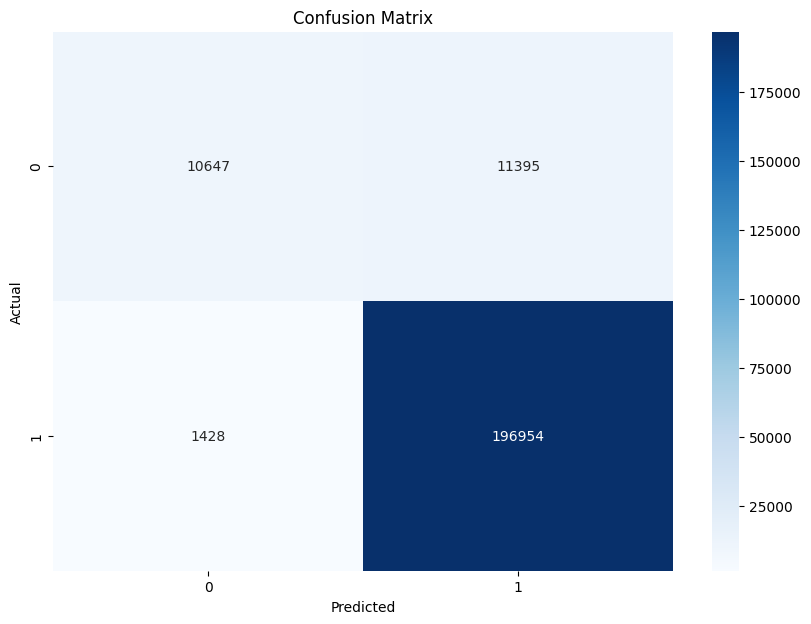

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_true are the true labels and y_pred are the predicted labels
conf_matrix = confusion_matrix(testy, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


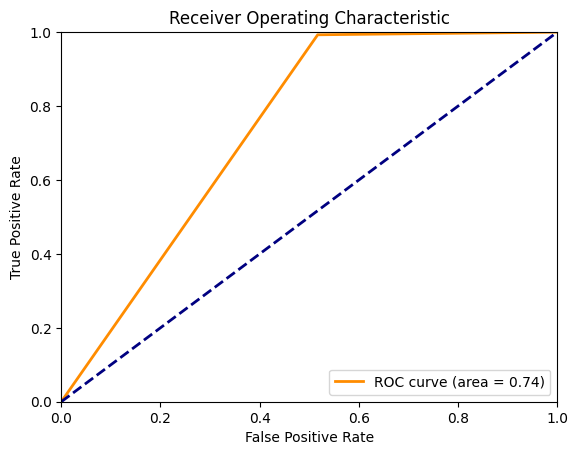

In [55]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(testy, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


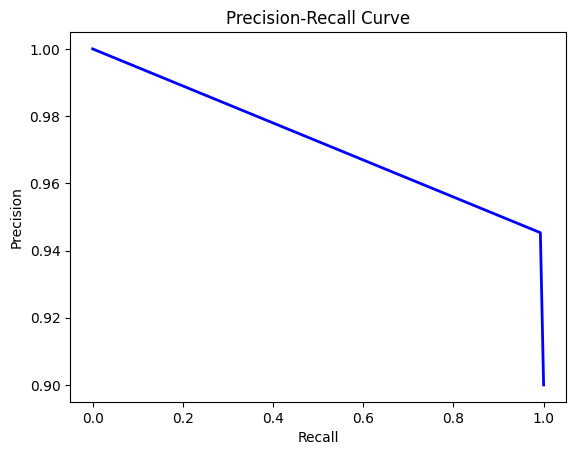

In [56]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(testy, y_pred)

plt.figure()
plt.plot(recall, precision, color='blue', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


[[0.000e+00 0.000e+00 0.000e+00 ... 1.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 5.200e+02 0.000e+00 ... 1.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 1.000e+00 1.000e+00 0.000e+00]
 ...
 [0.000e+00 1.032e+03 0.000e+00 ... 1.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 5.200e+02 0.000e+00 ... 1.000e+00 1.000e+00 0.000e+00]
 [0.000e+00 1.032e+03 0.000e+00 ... 1.000e+00 1.000e+00 0.000e+00]]
[[0.0000e+00 2.2500e+02 7.3600e+02 ... 1.0000e+00 1.0000e+00 0.0000e+00]
 [0.0000e+00 3.3600e+02 3.2100e+02 ... 1.0000e+00 1.0000e+00 0.0000e+00]
 [0.0000e+00 2.2700e+02 1.7372e+04 ... 1.0000e+00 1.0000e+00 0.0000e+00]
 ...
 [0.0000e+00 3.2400e+02 7.6200e+02 ... 1.0000e+00 1.0000e+00 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00 ... 1.0000e+00 1.0000e+00 0.0000e+00]
 [0.0000e+00 2.0200e+02 7.8400e+02 ... 1.0000e+00 1.0000e+00 0.0000e+00]]


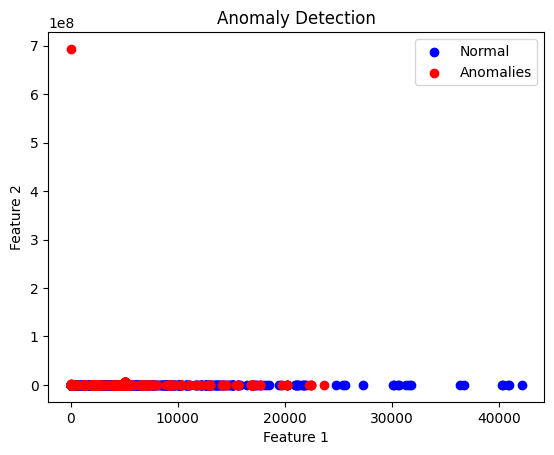

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming testx is your dataset and y_pred are the anomaly labels (-1 for anomalies, 1 for normal)
anomalies = testx[y_pred == -1]
normal = testx[y_pred == 1]
print(normal)
print(anomalies)

# Select the first two features for visualization
plt.scatter(normal[:, 0], normal[:, 1], c='blue', label='Normal')
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='red', label='Anomalies')
plt.title('Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


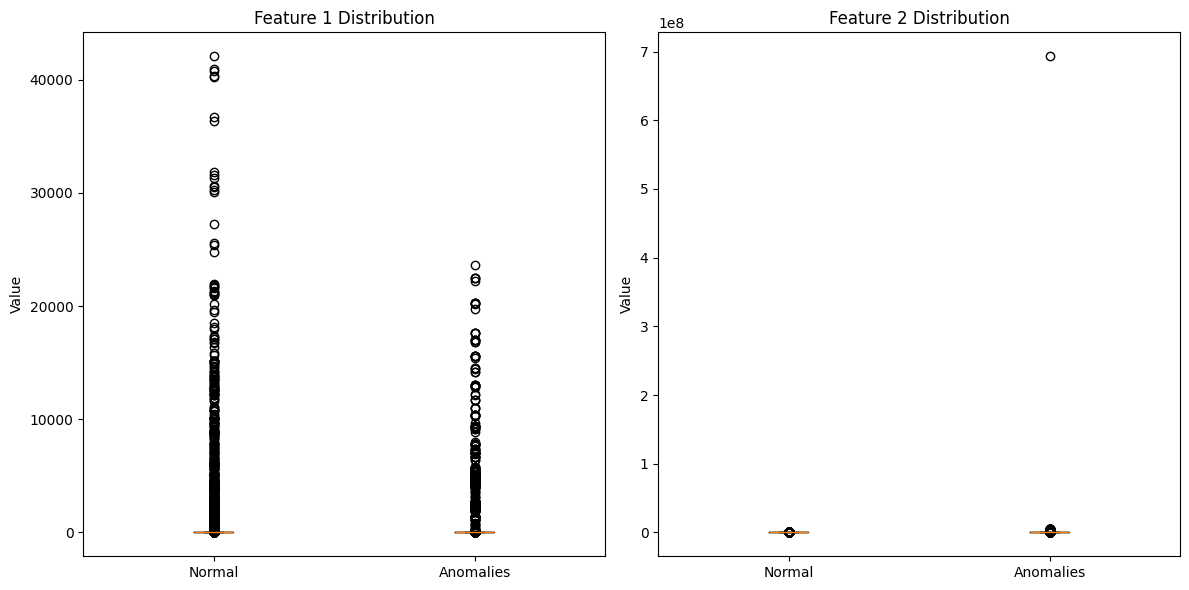

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming testx is your dataset and y_pred are the anomaly labels (-1 for anomalies, 1 for normal)
anomalies = testx[y_pred == -1]
normal = testx[y_pred == 1]

# Create a box plot for the first two features
plt.figure(figsize=(12, 6))

# Feature 1
plt.subplot(1, 2, 1)
plt.boxplot([normal[:, 0], anomalies[:, 0]], labels=['Normal', 'Anomalies'])
plt.title('Feature 1 Distribution')
plt.ylabel('Value')

# Feature 2
plt.subplot(1, 2, 2)
plt.boxplot([normal[:, 1], anomalies[:, 1]], labels=['Normal', 'Anomalies'])
plt.title('Feature 2 Distribution')
plt.ylabel('Value')

plt.tight_layout()
plt.show()


In [59]:
print(testy.shape,y_pred.shape)
print('testy -1:',(testy == -1).sum())
print('y_pred -1:',(y_pred == -1).sum())
posi_num = 0

for i in range(0, len(testy)):
    if testy[i] == y_pred[i] and testy[i] == -1:
        posi_num += 1
print('posi_num', posi_num)
n_errors = (y_pred != testy).sum()

print("Total errors:", n_errors, "Accuracy:", 1 - n_errors / testx.shape[0], 'Precision:', posi_num / (y_pred == -1).sum(), 'Recall', posi_num / (testy == -1).sum())
"""
(220424,) (220424,)
testy -1: 22042
y_pred -1: 24711
posi_num 3
Total errors: 46747 Accuracy: 0.7879223678002395 Precision: 0.00012140342357654485 Recall 0.00013610380183286453
[Finished in 376.3s]
"""

(220424,) (220424,)
testy -1: 22042
y_pred -1: 12075
posi_num 10647
Total errors: 12823 Accuracy: 0.9418257540013791 Precision: 0.8817391304347826 Recall 0.4830323927048362


'\n(220424,) (220424,)\ntesty -1: 22042\ny_pred -1: 24711\nposi_num 3\nTotal errors: 46747 Accuracy: 0.7879223678002395 Precision: 0.00012140342357654485 Recall 0.00013610380183286453\n[Finished in 376.3s]\n'